# Лабораторная работа 11 — Ансамбли: бэггинг

**Цель работы:** изучить метод бэггинга, построить ансамбли на основе разных базовых моделей и сравнить их качество на датасете GTZAN.

## Теоретическое введение

### Бэггинг (Bootstrap Aggregating)

**Бэггинг** — метод ансамблирования, при котором обучается несколько моделей на случайных подвыборках (bootstrap-выборках) из обучающих данных, а затем их предсказания усредняются (для регрессии) или определяются голосованием большинства (для классификации).

**Bootstrap-выборка** — выборка размером $N$ из исходного набора размером $N$, полученная **с возвратом**. В среднем ~63.2% уникальных объектов попадают в каждую подвыборку, остальные ~36.8% составляют **Out-of-Bag (OOB)** набор, который можно использовать для оценки качества.

### Почему бэггинг работает

Ошибку модели можно разложить: $\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Noise}$

Бэггинг **снижает дисперсию** (variance), не увеличивая смещение (bias). Это особенно эффективно для моделей с высокой дисперсией — например, деревьев решений без ограничений. Для стабильных моделей (логистическая регрессия, KNN) эффект менее выражен.

### BaggingClassifier в scikit-learn

Класс `BaggingClassifier` принимает любой базовый классификатор (`estimator`) и создаёт ансамбль из `n_estimators` копий, обученных на bootstrap-подвыборках. Параметры `max_samples` и `max_features` контролируют размер подвыборок.

## 1. Загрузка и предобработка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

df = pd.read_csv('../datasets/gtzan/features_30_sec.csv')
X = df.drop(columns=['filename', 'label', 'length'])
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'Датасет: {X.shape[0]} сэмплов, {X.shape[1]} признаков, {len(le.classes_)} классов')
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Датасет: 1000 сэмплов, 57 признаков, 10 классов
Train: 800, Test: 200


## 2. Базовые модели vs Бэггинг-ансамбли

Обучим три базовые модели (Decision Tree, Logistic Regression, KNN) отдельно и в составе бэггинг-ансамблей, чтобы наглядно увидеть эффект ансамблирования.

In [2]:
base_models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
}

bagging_models = {
    'Bagging + DT': BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=50, random_state=42, n_jobs=-1),
    'Bagging + LR': BaggingClassifier(
        estimator=LogisticRegression(max_iter=2000, random_state=42),
        n_estimators=50, random_state=42, n_jobs=-1),
    'Bagging + KNN': BaggingClassifier(
        estimator=KNeighborsClassifier(n_neighbors=5),
        n_estimators=50, random_state=42, n_jobs=-1),
}

results = {}

print('=== Базовые модели ===')
for name, model in base_models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = acc
    print(f'  {name}: accuracy = {acc:.4f}')

print('\n=== Бэггинг-ансамбли (50 моделей) ===')
for name, model in bagging_models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = acc
    print(f'  {name}: accuracy = {acc:.4f}')

=== Базовые модели ===


  Decision Tree: accuracy = 0.5050


  Logistic Regression: accuracy = 0.7100


  KNN (k=5): accuracy = 0.6800

=== Бэггинг-ансамбли (50 моделей) ===


  Bagging + DT: accuracy = 0.6750


  Bagging + LR: accuracy = 0.7100


  Bagging + KNN: accuracy = 0.7000


### 2.1 Визуализация: базовые модели vs бэггинг

Сравним accuracy базовых моделей и их бэггинг-ансамблей. Бэггинг наиболее эффективен для нестабильных моделей (деревья), менее — для стабильных (LR, KNN).

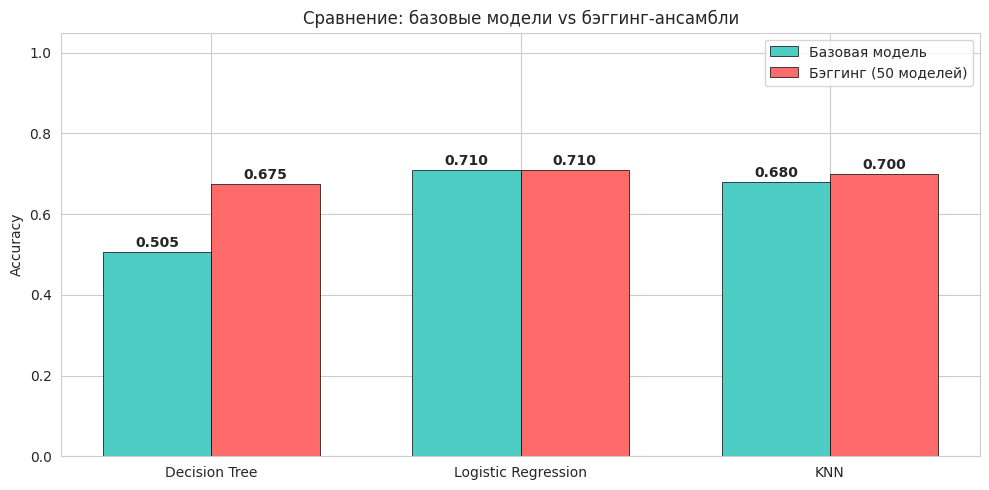

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(3)
width = 0.35
base_accs = [results['Decision Tree'], results['Logistic Regression'], results['KNN (k=5)']]
bag_accs = [results['Bagging + DT'], results['Bagging + LR'], results['Bagging + KNN']]
labels = ['Decision Tree', 'Logistic Regression', 'KNN']

bars1 = ax.bar(x_pos - width/2, base_accs, width, label='Базовая модель',
               color='#4ECDC4', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x_pos + width/2, bag_accs, width, label='Бэггинг (50 моделей)',
               color='#FF6B6B', edgecolor='black', linewidth=0.5)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel('Accuracy')
ax.set_title('Сравнение: базовые модели vs бэггинг-ансамбли')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 3. Оценка лучшего ансамбля

Подробно оценим лучший бэггинг-ансамбль: confusion matrix и classification report.

=== Bagging + Decision Tree (50 деревьев) ===
              precision    recall  f1-score   support

       blues       0.72      0.65      0.68        20
   classical       0.83      0.95      0.88        20
     country       0.68      0.75      0.71        20
       disco       0.47      0.40      0.43        20
      hiphop       0.54      0.75      0.62        20
        jazz       0.68      0.75      0.71        20
       metal       0.94      0.85      0.89        20
         pop       0.75      0.75      0.75        20
      reggae       0.56      0.50      0.53        20
        rock       0.57      0.40      0.47        20

    accuracy                           0.68       200
   macro avg       0.67      0.68      0.67       200
weighted avg       0.67      0.68      0.67       200



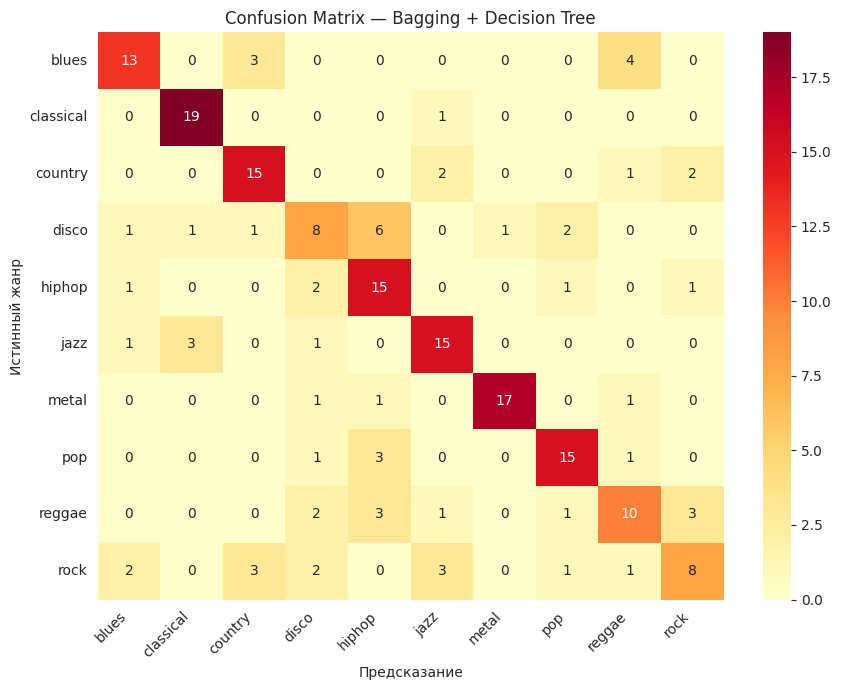

In [4]:
# Лучший ансамбль — Bagging + DT
best_bag = bagging_models['Bagging + DT']
y_pred_best = best_bag.predict(X_test)

print('=== Bagging + Decision Tree (50 деревьев) ===')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_xlabel('Предсказание')
ax.set_ylabel('Истинный жанр')
ax.set_title('Confusion Matrix — Bagging + Decision Tree')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. ROC-кривые — сравнение ансамблей

Построим micro-average ROC-кривые для всех трёх бэггинг-ансамблей.

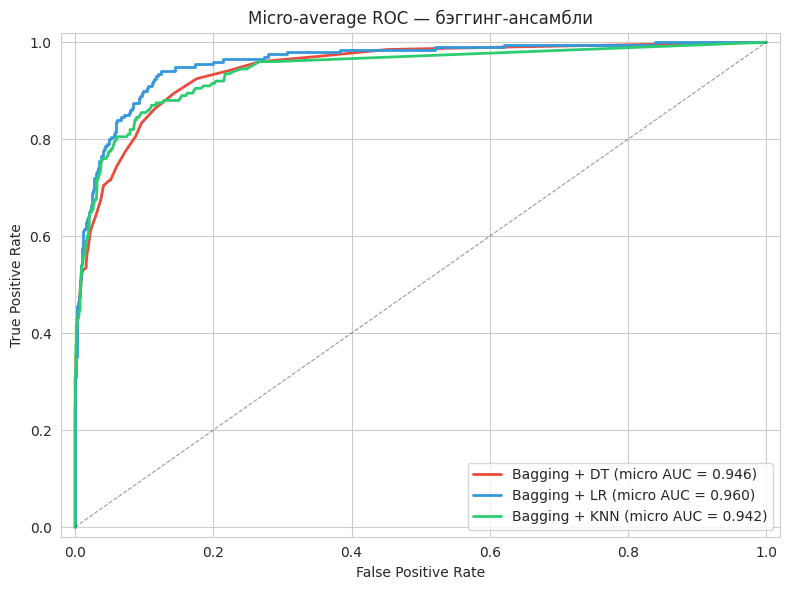

In [5]:
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71']

for (name, model), color in zip(bagging_models.items(), colors):
    y_proba = model.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (micro AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Micro-average ROC — бэггинг-ансамбли')
ax.legend(loc='lower right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

## 5. Влияние числа моделей в ансамбле

Исследуем, как количество деревьев в бэггинге (`n_estimators`) влияет на accuracy. С увеличением числа моделей качество растёт и стабилизируется.

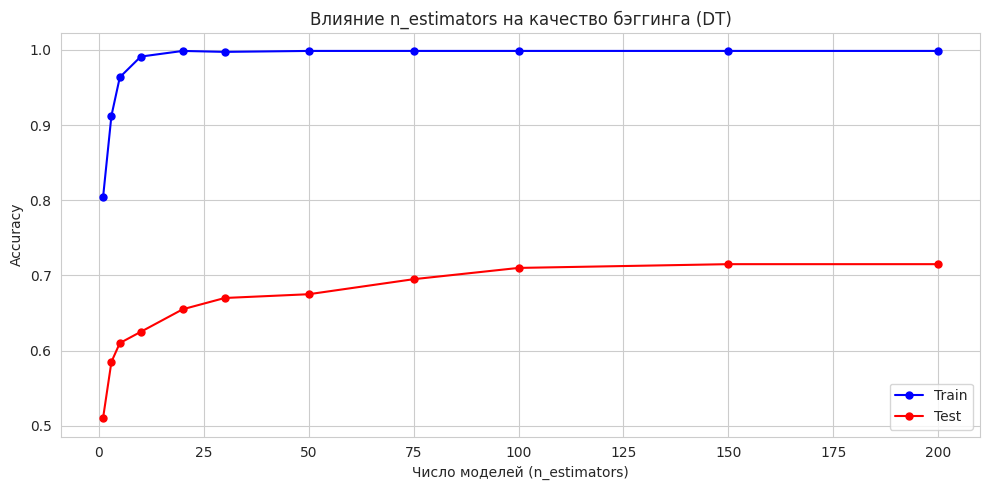

Лучший n_estimators: 150, accuracy = 0.7150


In [6]:
n_range = [1, 3, 5, 10, 20, 30, 50, 75, 100, 150, 200]
train_scores, test_scores = [], []

for n in n_range:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=n, random_state=42, n_jobs=-1
    )
    bag.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, bag.predict(X_train)))
    test_scores.append(accuracy_score(y_test, bag.predict(X_test)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_range, train_scores, 'b-o', markersize=5, label='Train')
ax.plot(n_range, test_scores, 'r-o', markersize=5, label='Test')
ax.set_xlabel('Число моделей (n_estimators)')
ax.set_ylabel('Accuracy')
ax.set_title('Влияние n_estimators на качество бэггинга (DT)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Лучший n_estimators: {n_range[np.argmax(test_scores)]}, accuracy = {max(test_scores):.4f}')

## 6. Важность признаков (средняя по деревьям ансамбля)

Бэггинг на деревьях позволяет оценить важность признаков, усреднив `feature_importances_` по всем деревьям ансамбля.

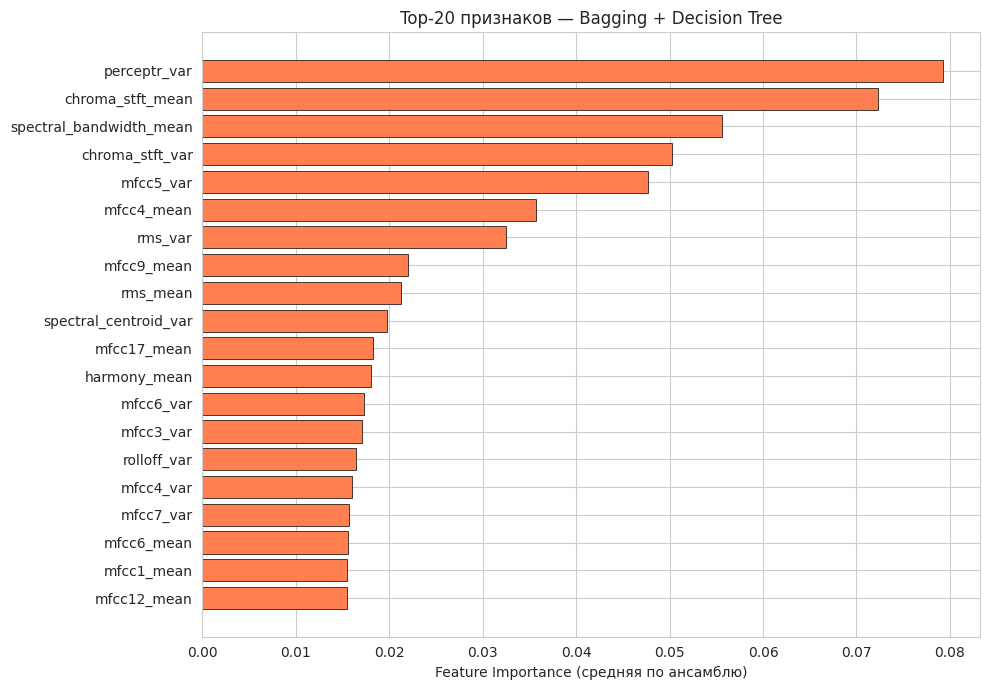

In [7]:
importances = np.mean(
    [tree.feature_importances_ for tree in best_bag.estimators_], axis=0
)
imp_df = pd.DataFrame({'Признак': feature_names, 'Важность': importances})
imp_df = imp_df.sort_values('Важность', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df['Признак'], imp_df['Важность'], color='coral',
        edgecolor='black', linewidth=0.5)
ax.set_xlabel('Feature Importance (средняя по ансамблю)')
ax.set_title('Top-20 признаков — Bagging + Decision Tree')
plt.tight_layout()
plt.show()

## 7. Кросс-валидация — сравнение всех моделей

Стратифицированная 5-fold кросс-валидация для объективного сравнения базовых моделей и бэггинг-ансамблей.

DT      : 0.5140 ± 0.0372


LR      : 0.7070 ± 0.0163


KNN     : 0.6730 ± 0.0343


Bag+DT  : 0.6860 ± 0.0463


Bag+LR  : 0.7170 ± 0.0186


Bag+KNN : 0.6950 ± 0.0344


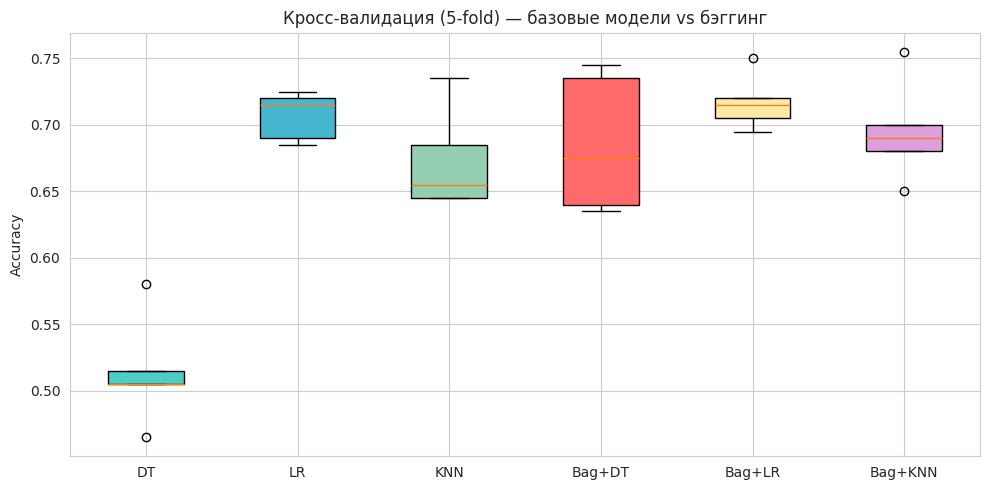

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_models = {
    'DT': DecisionTreeClassifier(random_state=42),
    'LR': LogisticRegression(max_iter=2000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Bag+DT': BaggingClassifier(DecisionTreeClassifier(random_state=42),
                                 n_estimators=50, random_state=42, n_jobs=-1),
    'Bag+LR': BaggingClassifier(LogisticRegression(max_iter=2000, random_state=42),
                                 n_estimators=50, random_state=42, n_jobs=-1),
    'Bag+KNN': BaggingClassifier(KNeighborsClassifier(n_neighbors=5),
                                  n_estimators=50, random_state=42, n_jobs=-1),
}

cv_results = {}
for name, model in all_models.items():
    scores = cross_val_score(model, X_scaled, y_encoded, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:8s}: {scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot([cv_results[n] for n in cv_results],
                labels=list(cv_results.keys()), patch_artist=True)
colors_box = ['#4ECDC4', '#45B7D1', '#96CEB4', '#FF6B6B', '#FFEAA7', '#DDA0DD']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
ax.set_ylabel('Accuracy')
ax.set_title('Кросс-валидация (5-fold) — базовые модели vs бэггинг')
plt.tight_layout()
plt.show()

## Выводы

1. **Бэггинг** существенно улучшает качество нестабильных моделей (Decision Tree): ансамбль из 50 деревьев значительно превосходит одиночное дерево за счёт снижения дисперсии.

2. Для **стабильных моделей** (Logistic Regression, KNN) эффект бэггинга менее выражен, так как у них низкая дисперсия — усреднение похожих моделей даёт небольшой прирост.

3. **Увеличение n_estimators** повышает accuracy до определённого предела (обычно 50-100 деревьев), после чего кривая выходит на плато.

4. **ROC-анализ** подтверждает, что бэггинг на деревьях даёт наилучший micro-average AUC среди рассмотренных ансамблей.

5. **Наиболее важные признаки** (MFCC, спектральные характеристики) совпадают с результатами Random Forest из предыдущей лабораторной, что подтверждает устойчивость оценки.

6. Бэггинг — простой и эффективный метод ансамблирования, но для дальнейшего улучшения стоит рассмотреть **бустинг** (следующая лабораторная), который целенаправленно исправляет ошибки предыдущих моделей.